### Soal 1

 EKSPLORASI GREEDY BEST FIRST SEARCH (BFS)
Mengunjungi Node 'S' (Nilai Heuristik: 10)
Mengunjungi Node 'A' (Nilai Heuristik: 5)
Mengunjungi Node 'C' (Nilai Heuristik: 3)
Mengunjungi Node 'G' (Nilai Heuristik: 0)

✅ Pesan Konfirmasi: Node tujuan berhasil ditemukan!
Jalur lengkap dari node asal ke node tujuan: S -> A -> C -> G


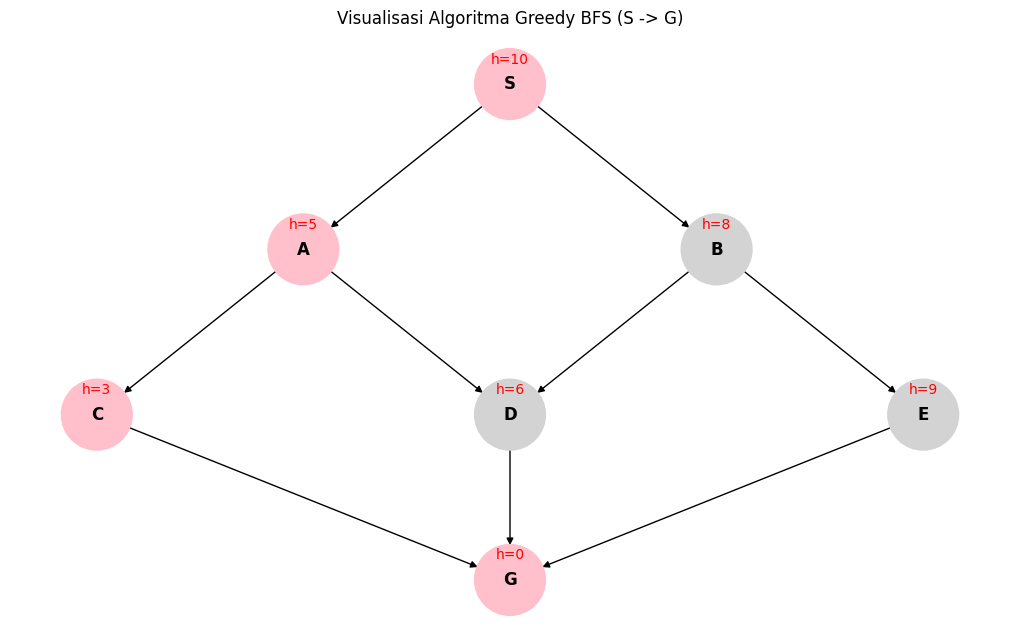

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq

# 1. REPRESENTASI GRAPH (Adjacency List)
graph = { 
    'S': ['A', 'B'], 
    'A': ['C', 'D'], 
    'B': ['D', 'E'], 
    'C': ['G'], 
    'D': ['G'], 
    'E': ['G'], 
    'G': [] 
} 

# 2. NILAI HEURISTIK
heuristic = { 
    'S': 10, 
    'A': 5, 
    'B': 8, 
    'C': 3, 
    'D': 6, 
    'E': 9, 
    'G': 0 
} 

# 3. FUNGSI GREEDY BEST FIRST SEARCH (GBFS)
def greedy_bfs(graph_adj, heuristic_dict, start, goal):
    # Priority queue (modul heapq) untuk menyimpan node yang akan dieksplorasi
    pq = []
    heapq.heappush(pq, (heuristic_dict[start], start, [start]))
    
    # Visited set untuk mencegah node dikunjungi lebih dari satu kali
    visited = set()
    
    print("=" * 50)
    print(" EKSPLORASI GREEDY BEST FIRST SEARCH (BFS)")
    print("=" * 50)
    
    while pq:
        # Setiap langkah memilih node dengan nilai heuristik terkecil
        h_val, current_node, path = heapq.heappop(pq)
        
        # Mencegah node dikunjungi berulang kali
        if current_node in visited:
            continue
            
        visited.add(current_node)
        
        # Menampilkan setiap node yang dikunjungi beserta nilai heuristiknya
        print(f"Mengunjungi Node '{current_node}' (Nilai Heuristik: {h_val})")
        
        # Cek apakah node tujuan berhasil ditemukan
        if current_node == goal:
            print("\n✅ Pesan Konfirmasi: Node tujuan berhasil ditemukan!")
            print(f"Jalur lengkap dari node asal ke node tujuan: {' -> '.join(path)}")
            return path
            
        # Memasukkan tetangga ke dalam antrean (eksplorasi adjacency list)
        for neighbor in graph_adj.get(current_node, []):
            if neighbor not in visited:
                heapq.heappush(pq, (heuristic_dict[neighbor], neighbor, path + [neighbor]))
                
    # Jika node tujuan tidak ditemukan
    print('\n"Node tujuan tidak dapat ditemukan."')
    return []

# Menjalankan algoritma
jalur_ditemukan = greedy_bfs(graph, heuristic, 'S', 'G')

# 4. VISUALISASI MENGGUNAKAN NETWORKX (Format yang Anda pelajari)
# Membuat Directed Graph (Graph Berarah) dari Adjacency List
G = nx.DiGraph(graph)

# Menentukan posisi manual agar grafiknya berbentuk pohon (tree) yang rapi ke bawah
pos = {
    'S': (0, 3), 
    'A': (-1, 2), 
    'B': (1, 2), 
    'C': (-2, 1), 
    'D': (0, 1), 
    'E': (2, 1), 
    'G': (0, 0)
}

plt.figure(figsize=(10, 6))

# Mewarnai node: hijau jika masuk dalam jalur yang ditemukan, abu-abu jika tidak
node_colors = ['pink' if node in jalur_ditemukan else 'lightgrey' for node in G.nodes()]

# Menggambar node dan garis (edges)
nx.draw(G, pos, 
        with_labels=True, 
        node_color=node_colors, 
        node_shape='o',
        node_size=2500,
        font_size=12,
        font_weight='bold',
        edge_color='black',
        arrows=True,
        linewidths=2)

# Menambahkan label heuristik di atas setiap node
heuristik_labels = {node: f"h={heuristic[node]}" for node in G.nodes()}
# Sedikit menggeser posisi Y agar label heuristik tidak menabrak lingkaran node
pos_labels = {node: (x, y + 0.15) for node, (x, y) in pos.items()}
nx.draw_networkx_labels(G, pos_labels, labels=heuristik_labels, font_color='red', font_size=10)

plt.title("Visualisasi Algoritma Greedy BFS (S -> G)")
plt.axis('off')
plt.show()